<a href="https://colab.research.google.com/github/rickzzim/Aula7/blob/main/aula7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


 Generating plots for: a) Passa-baixas (fc=1000Hz)


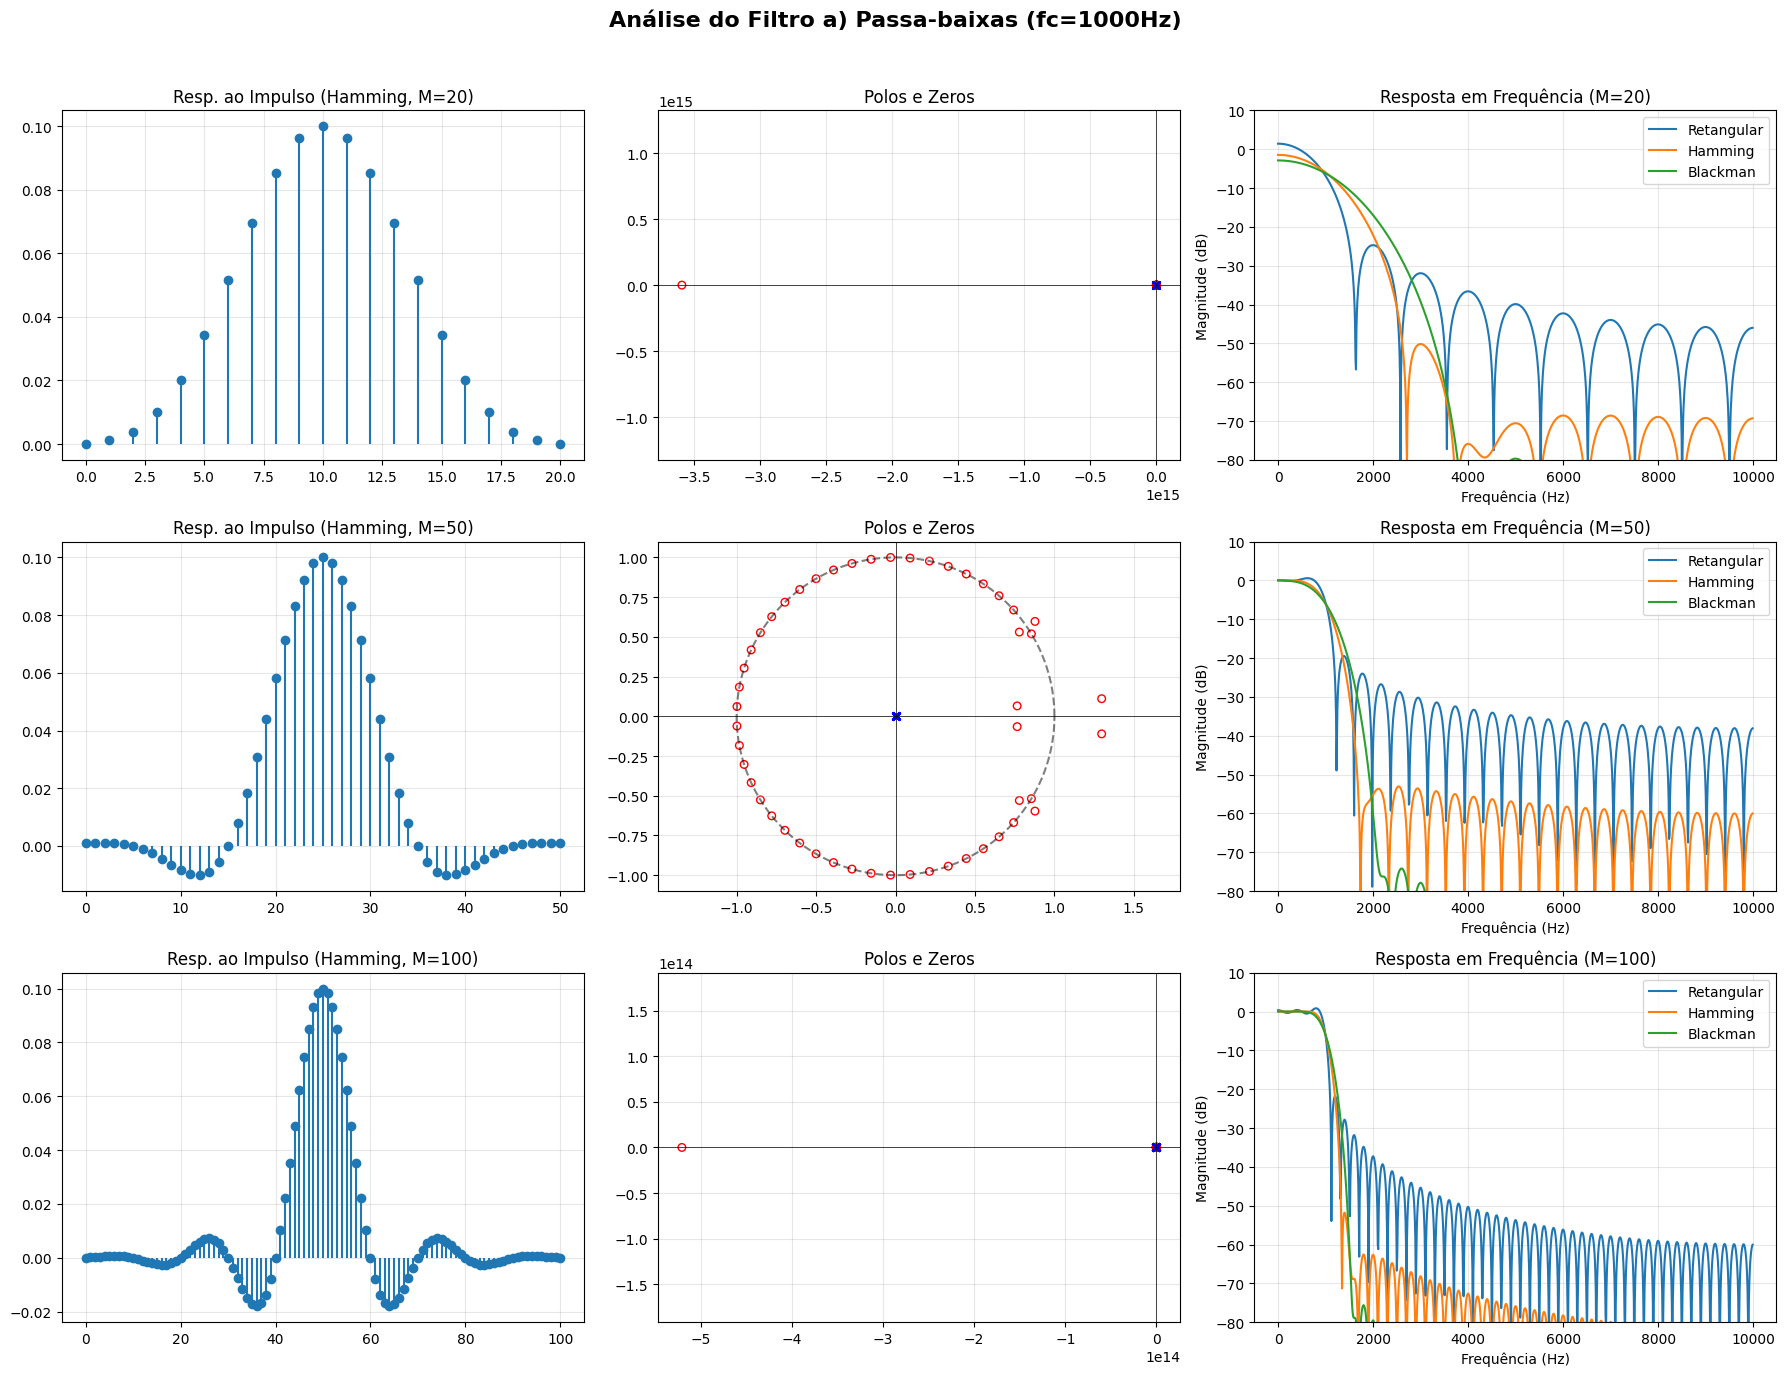


 Generating plots for: b) Passa-altas (fc=2000Hz)


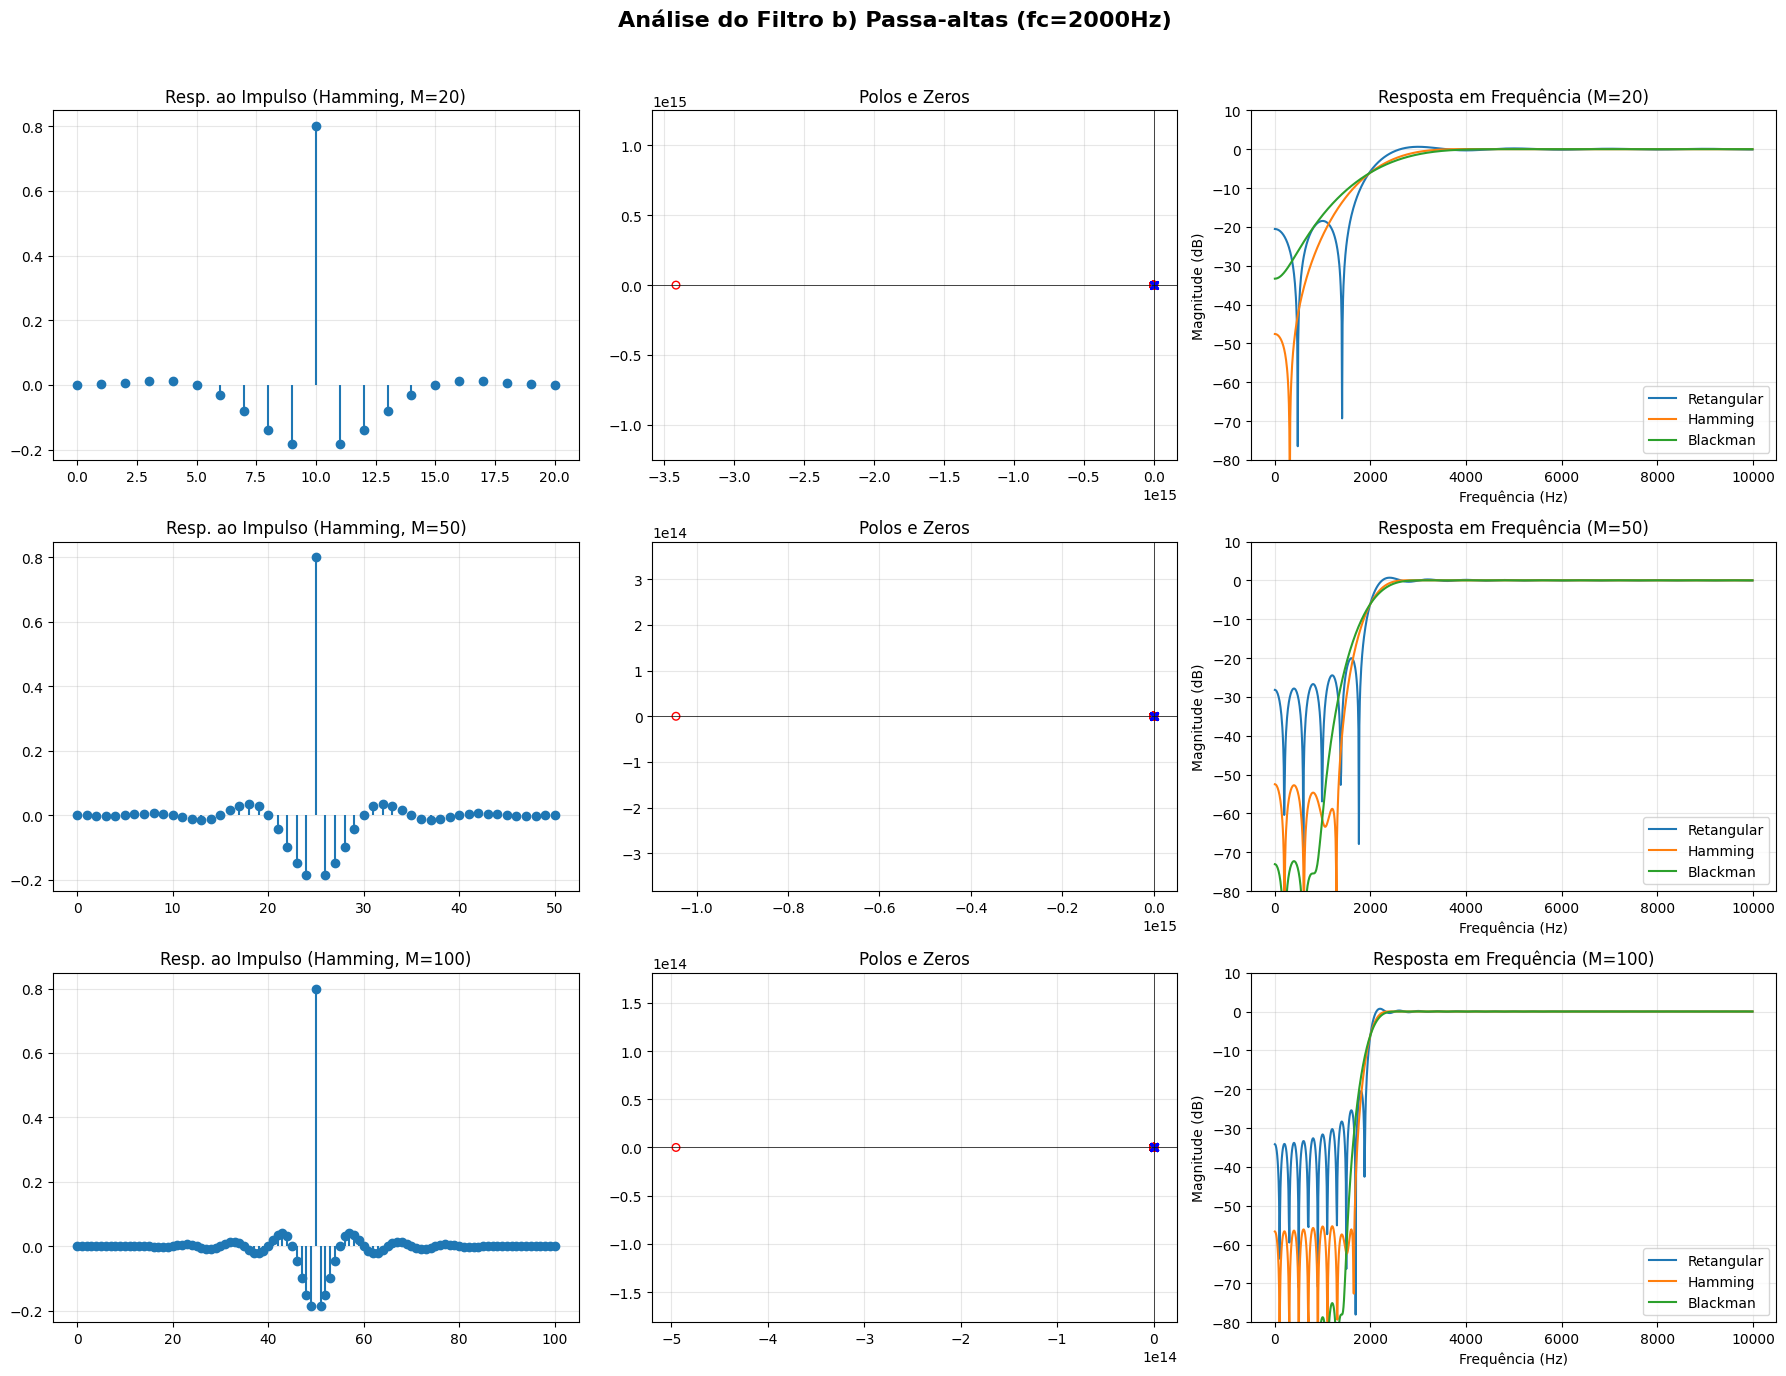


 Generating plots for: c) Passa-faixas (fc1=500Hz, fc2=2000Hz)


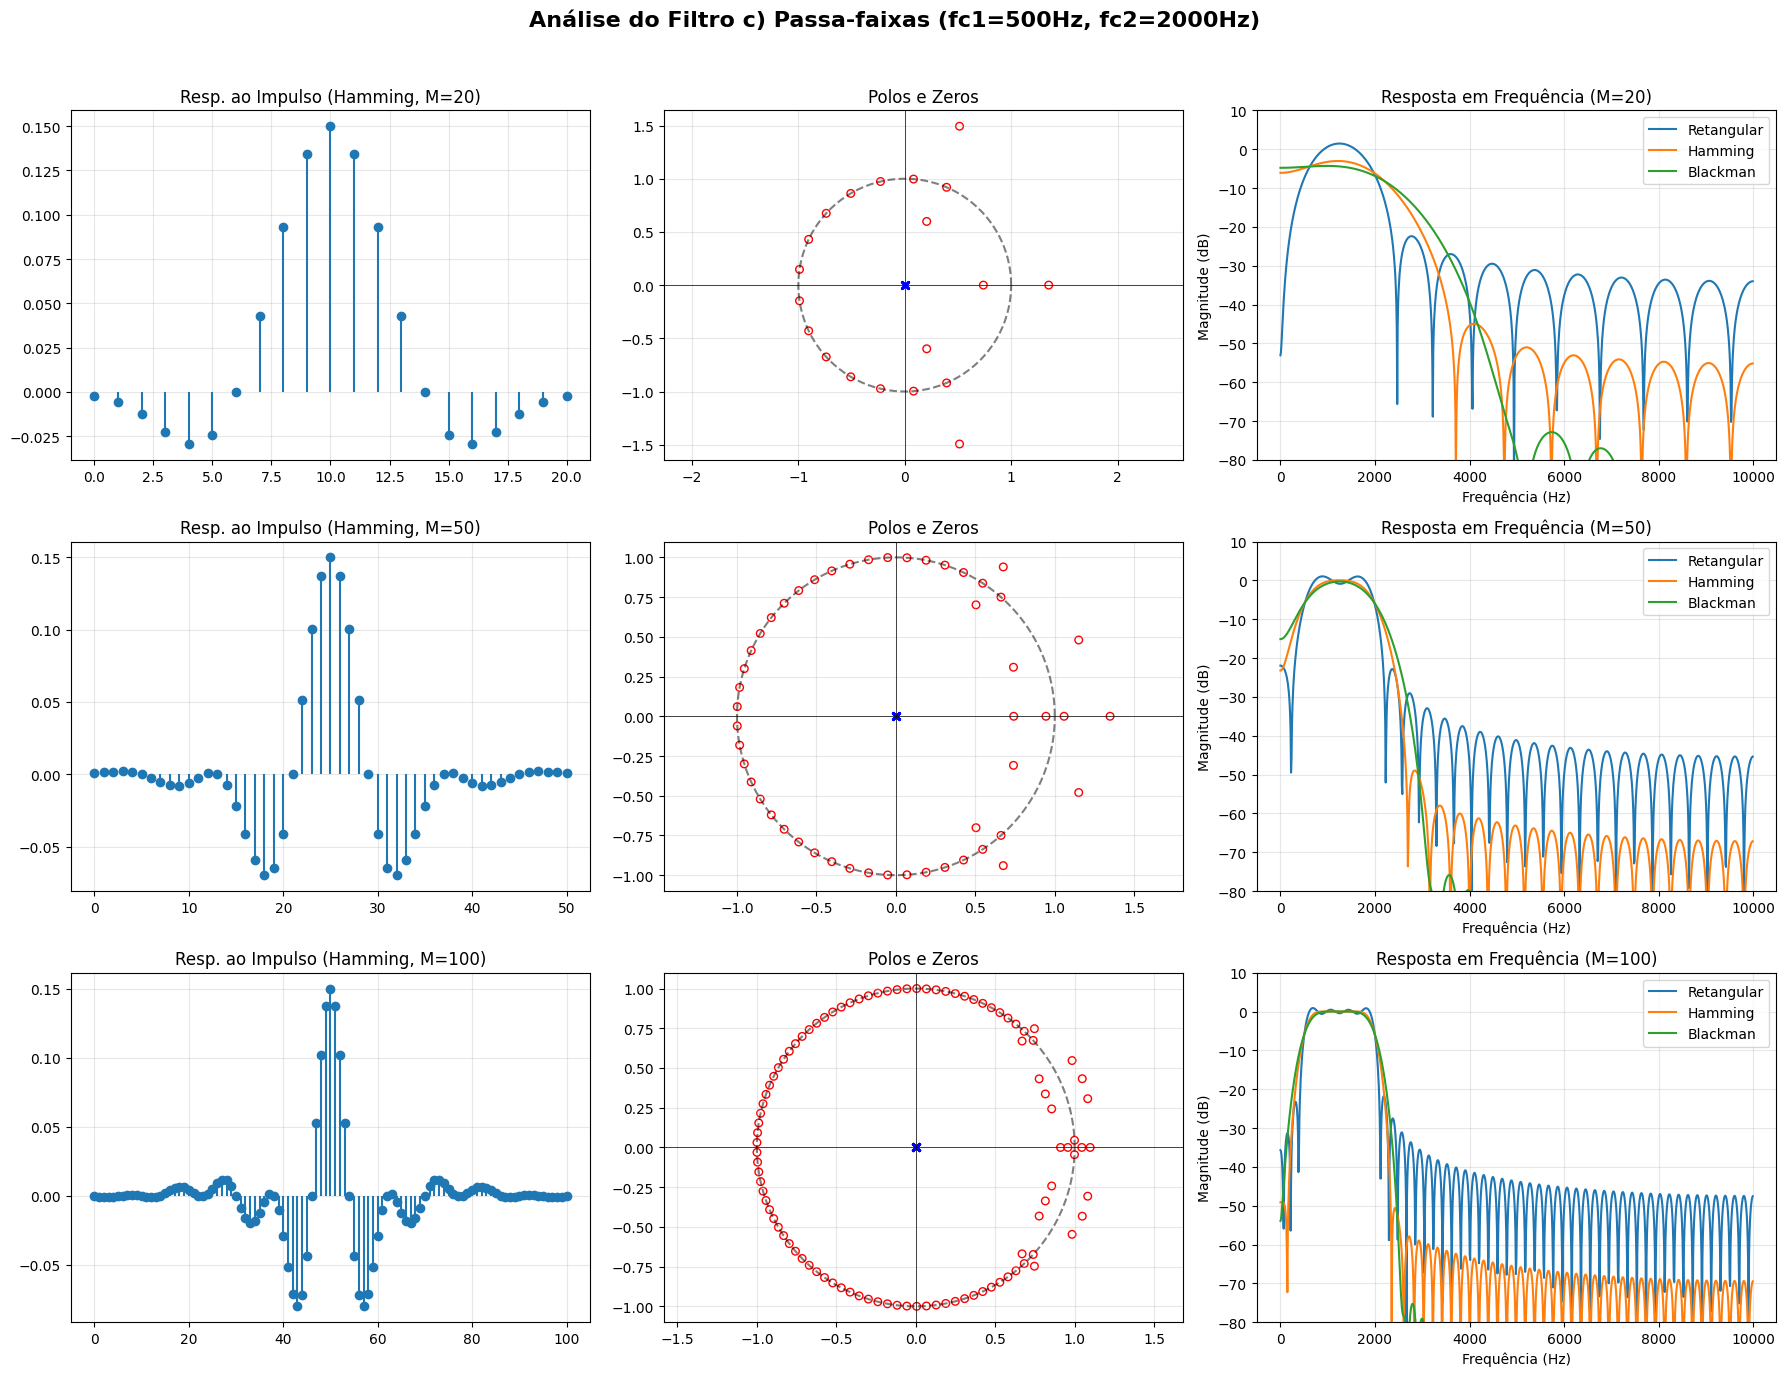


 Generating plots for: d) Rejeita-faixas (fc1=1000Hz, fc2=2500Hz)


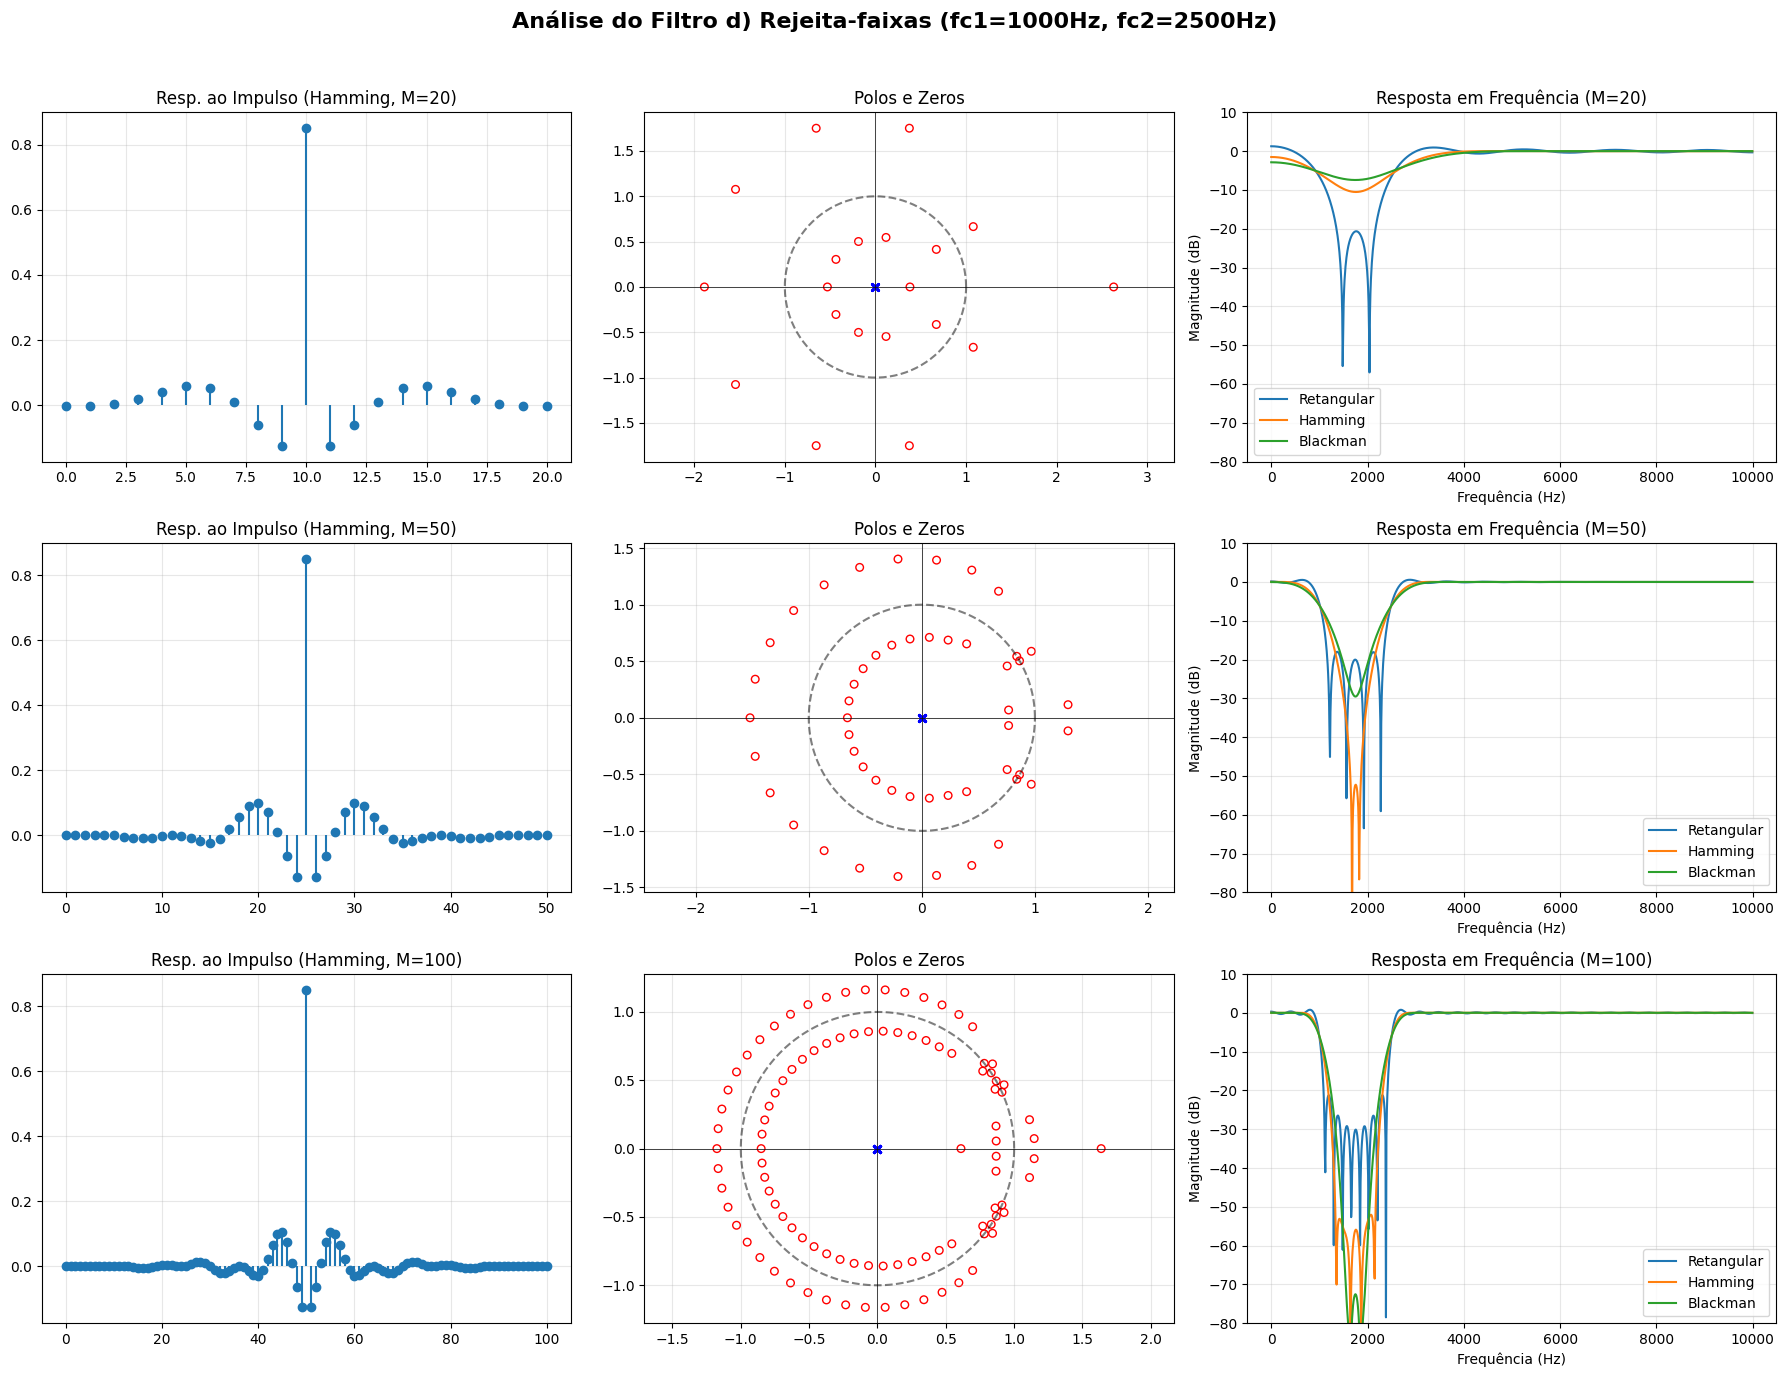

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Implementação Manual das Janelas (Tamanho N = M + 1)
def get_window(name, M):
    N = M + 1
    n = np.arange(N)
    if name == 'retangular':
        return np.ones(N)
    elif name == 'triangular' or name == 'bartlett':
        return 1.0 - np.abs(2 * n - M) / M
    elif name == 'hamming':
        return 0.54 - 0.46 * np.cos(2 * np.pi * n / M)
    elif name == 'hann':
        return 0.5 - 0.5 * np.cos(2 * np.pi * n / M)
    elif name == 'blackman':
        return 0.42 - 0.5 * np.cos(2 * np.pi * n / M) + 0.08 * np.cos(4 * np.pi * n / M)
    else:
        raise ValueError("Janela desconhecida")

# 2. Respostas ao Impulso Ideais (Deslocadas para n - M/2 para causalidade)
def ideal_impulse_response(filter_type, M, fs, f_c1, f_c2=None):
    N = M + 1
    n = np.arange(N) - M / 2.0

    # Frequências digitais radiais
    w_c1 = 2 * np.pi * f_c1 / fs
    w_c2 = 2 * np.pi * f_c2 / fs if f_c2 is not None else None

    h_ideal = np.zeros(N)

    for i, t in enumerate(n):
        if filter_type == 'passa_baixas':
            if t == 0:
                h_ideal[i] = w_c1 / np.pi
            else:
                h_ideal[i] = np.sin(w_c1 * t) / (np.pi * t)

        elif filter_type == 'passa_altas':
            if t == 0:
                h_ideal[i] = 1.0 - (w_c1 / np.pi)
            else:
                h_ideal[i] = -np.sin(w_c1 * t) / (np.pi * t)

        elif filter_type == 'passa_faixas':
            if t == 0:
                h_ideal[i] = (w_c2 - w_c1) / np.pi
            else:
                h_ideal[i] = (np.sin(w_c2 * t) - np.sin(w_c1 * t)) / (np.pi * t)

        elif filter_type == 'rejeita_faixas':
            if t == 0:
                h_ideal[i] = 1.0 - ((w_c2 - w_c1) / np.pi)
            else:
                h_ideal[i] = (np.sin(w_c1 * t) - np.sin(w_c2 * t)) / (np.pi * t)

    return h_ideal

# 3. Função Auxiliar para Plotar Diagrama de Polos e Zeros
def plot_zplane(h, ax):
    zeros = np.roots(h)
    poles = np.zeros(len(h) - 1) # Filtro FIR possui todos os polos na origem

    # Desenha o círculo unitário
    theta = np.linspace(0, 2*np.pi, 200)
    ax.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.5)
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='black', lw=0.5)

    # Plota zeros e polos
    ax.scatter(np.real(zeros), np.imag(zeros), s=30, facecolors='none', edgecolors='r', label='Zeros')
    ax.scatter(np.real(poles), np.imag(poles), s=30, color='b', marker='x', label='Polos')
    ax.set_title("Polos e Zeros")
    ax.axis('equal')
    ax.grid(True, alpha=0.3)

# --- EXECUÇÃO PRINCIPAL (QUESTÃO 1) ---
fs = 20000
filtros = {
    'a) Passa-baixas (fc=1000Hz)': ('passa_baixas', 1000, None),
    'b) Passa-altas (fc=2000Hz)': ('passa_altas', 2000, None),
    'c) Passa-faixas (fc1=500Hz, fc2=2000Hz)': ('passa_faixas', 500, 2000),
    'd) Rejeita-faixas (fc1=1000Hz, fc2=2500Hz)': ('rejeita_faixas', 1000, 2500)
}

janelas = ['retangular', 'hamming', 'blackman'] # Principais para visualização clara
ordens = [20, 50, 100]

for titulo, (ftype, fc1, fc2) in filtros.items():
    print(f"\n Generating plots for: {titulo}")
    fig, axes = plt.subplots(3, 3, figsize=(18, 14))
    fig.suptitle(f"Análise do Filtro {titulo}", fontsize=16, fontweight='bold')

    for idx_m, M in enumerate(ordens):
        # Usando Hamming como padrão para variar a ordem nesta linha de plots
        h_ideal = ideal_impulse_response(ftype, M, fs, fc1, fc2)
        w = get_window('hamming', M)
        h_fir = h_ideal * w

        # 1. Resposta ao impulso
        axes[idx_m, 0].stem(np.arange(M+1), h_fir, basefmt=" ")
        axes[idx_m, 0].set_title(f"Resp. ao Impulso (Hamming, M={M})")
        axes[idx_m, 0].grid(True, alpha=0.3)

        # 2. Diagrama de Polos e Zeros
        plot_zplane(h_fir, axes[idx_m, 1])

        # 3. Resposta em Frequência (Comparando Janelas para a mesma ordem M)
        for win_name in ['retangular', 'hamming', 'blackman']:
            w_spec = get_window(win_name, M)
            h_spec = ideal_impulse_response(ftype, M, fs, fc1, fc2) * w_spec

            # Cálculo da DFT (Frequência) via FFT para visualização
            H = np.fft.fft(h_spec, 2048)
            freqs = np.fft.fftfreq(2048, 1/fs)[:1024]
            mag = 20 * np.log10(np.abs(H[:1024]) + 1e-12)

            axes[idx_m, 2].plot(freqs, mag, label=win_name.capitalize())

        axes[idx_m, 2].set_title(f"Resposta em Frequência (M={M})")
        axes[idx_m, 2].set_xlabel("Frequência (Hz)")
        axes[idx_m, 2].set_ylabel("Magnitude (dB)")
        axes[idx_m, 2].set_ylim([-80, 10])
        axes[idx_m, 2].grid(True, alpha=0.3)
        axes[idx_m, 2].legend()

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

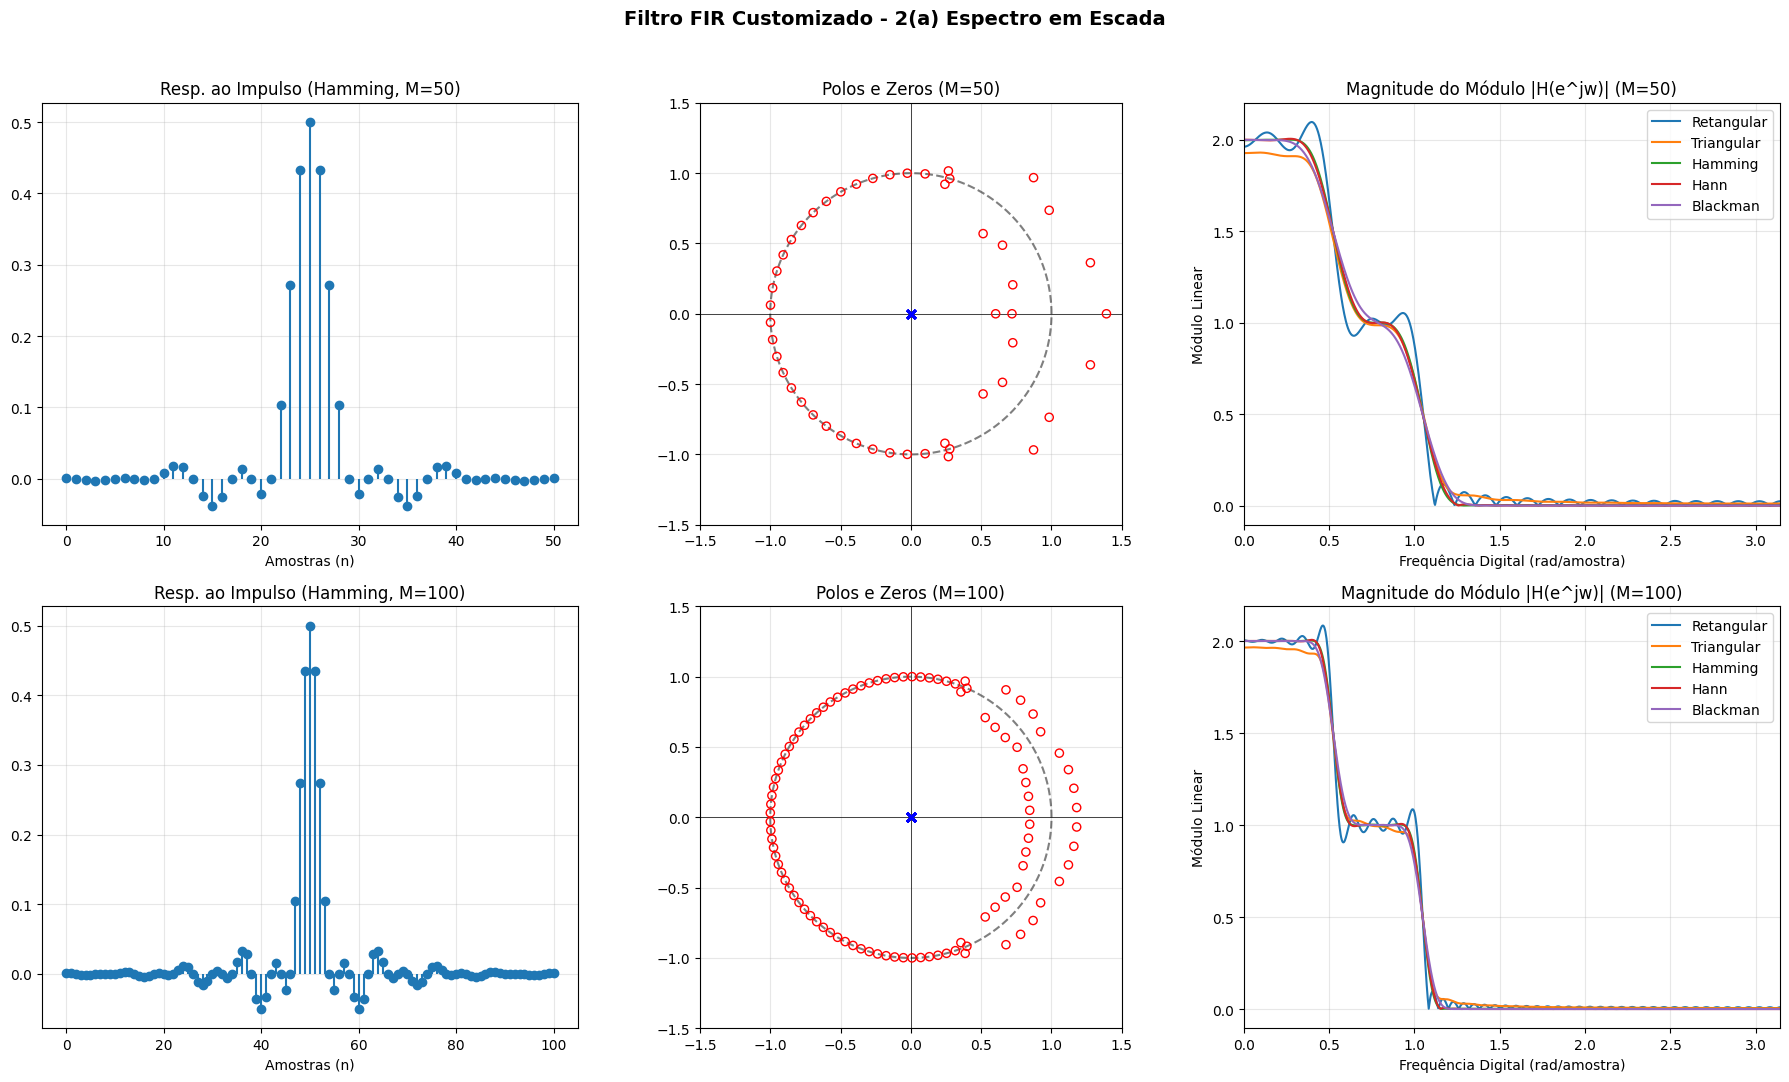

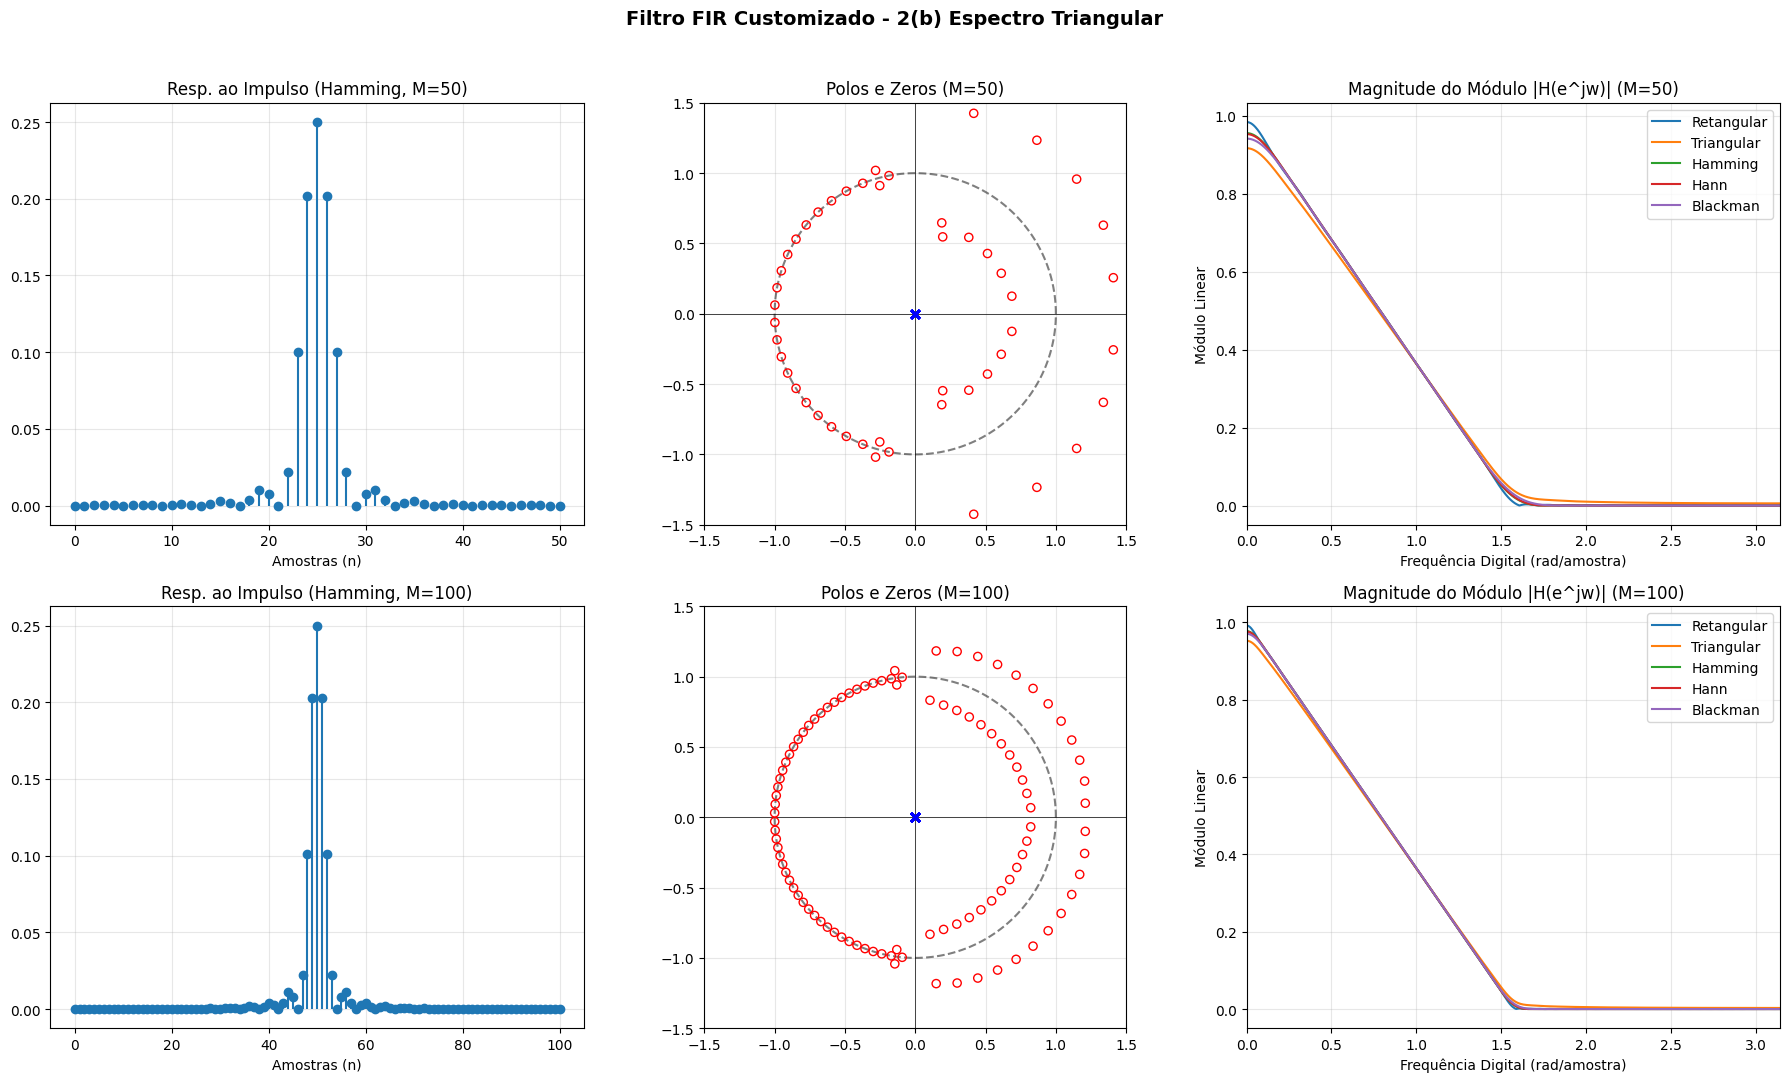

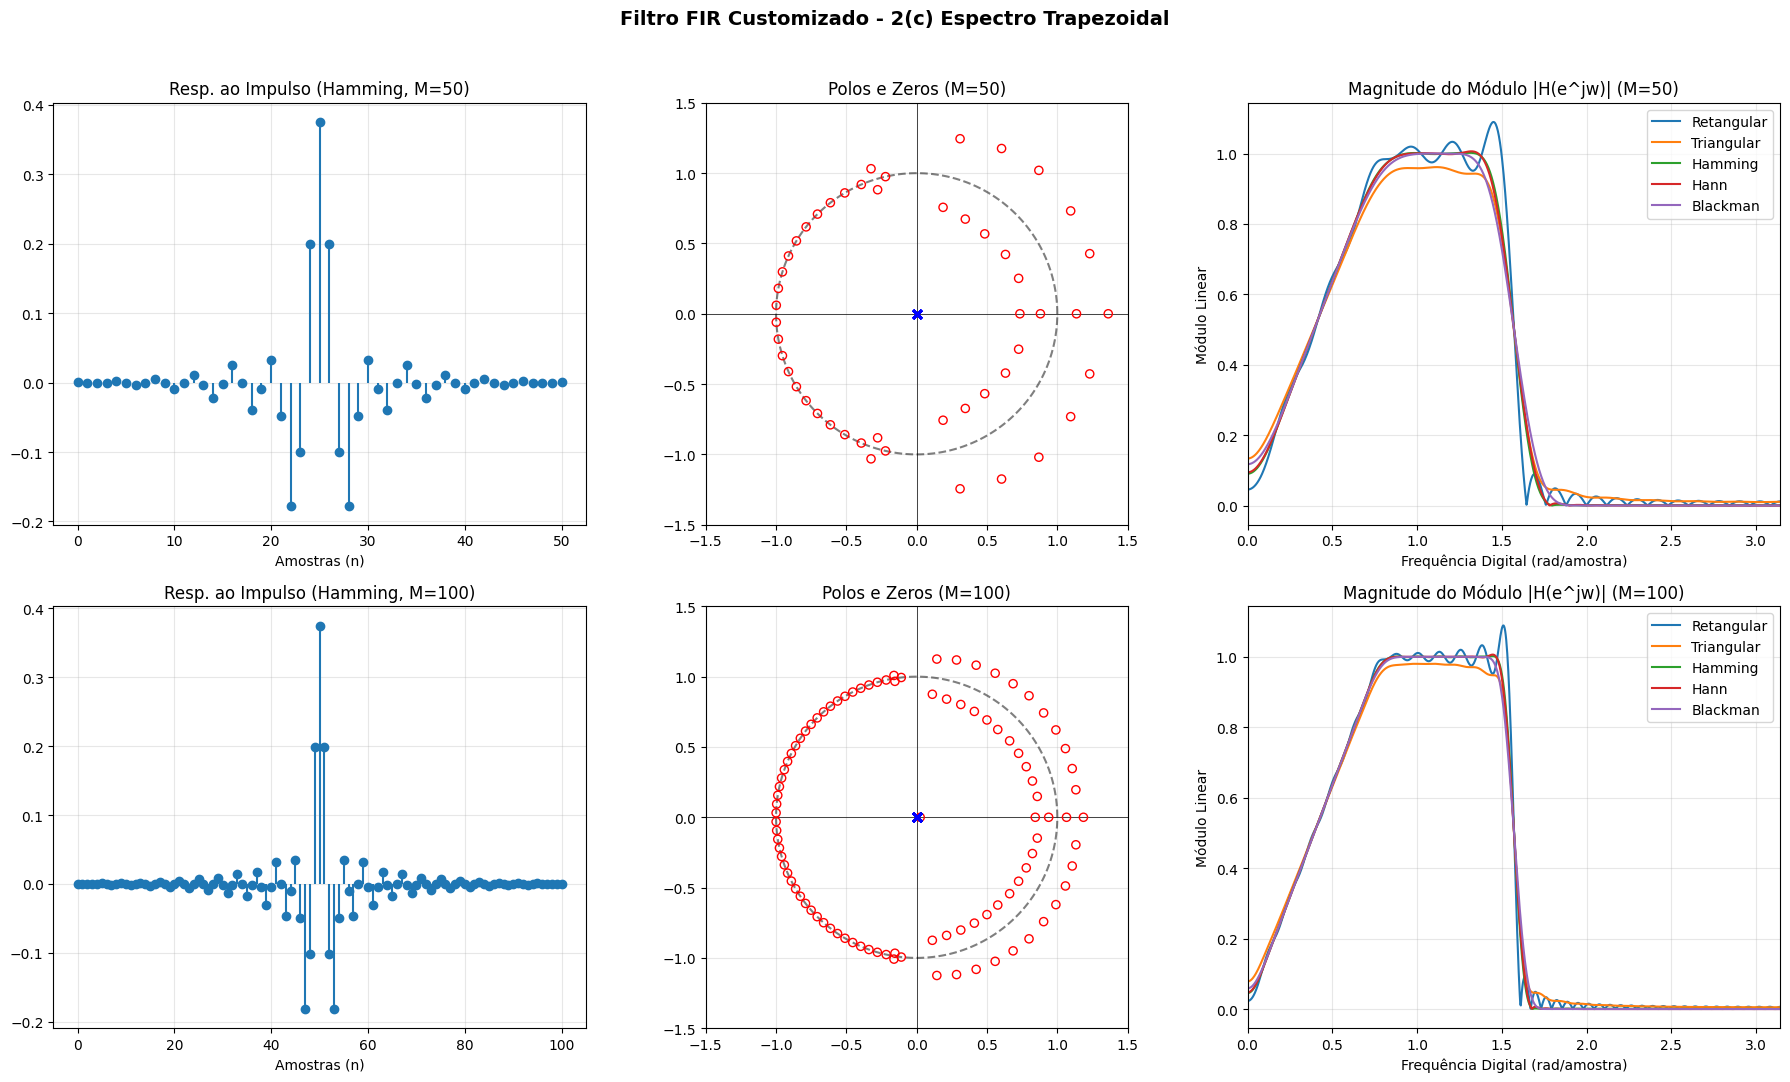

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. FUNÇÕES AUXILIARES DE PROJETO E CORREÇÃO
# =====================================================================

def get_window(name, M):
    """Retorna os coeficientes da janela baseada no nome e na ordem M."""
    N = M + 1
    n = np.arange(N)
    if name == 'retangular':
        return np.ones(N)
    elif name == 'triangular' or name == 'bartlett':
        return 1.0 - np.abs(2 * n - M) / M
    elif name == 'hamming':
        return 0.54 - 0.46 * np.cos(2 * np.pi * n / M)
    elif name == 'hann':
        return 0.5 * (1.0 - np.cos(2 * np.pi * n / M))
    elif name == 'blackman':
        return 0.42 - 0.5 * np.cos(2 * np.pi * n / M) + 0.08 * np.cos(4 * np.pi * n / M)
    else:
        raise ValueError(f"Janela '{name}' desconhecida.")

def plot_zplane_fixed(h, ax):
    """Plota o diagrama de polos e zeros com escala fixa para evitar distorções."""
    zeros = np.roots(h)
    poles = np.zeros(len(h) - 1)

    # Desenha o círculo unitário de referência
    theta = np.linspace(0, 2*np.pi, 200)
    ax.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.5)
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='black', lw=0.5)

    # Plota zeros (vermelho) e polos (azul)
    ax.scatter(np.real(zeros), np.imag(zeros), s=35, facecolors='none', edgecolors='r', label='Zeros', zorder=3)
    ax.scatter(np.real(poles), np.imag(poles), s=35, color='b', marker='x', label='Polos', zorder=3)

    # Correção da escala para focar no círculo unitário
    ax.set_xlim([-1.5, 1.5])
    ax.set_ylim([-1.5, 1.5])
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

# =====================================================================
# 2. DEDUÇÕES DA RESPOSTA AO IMPULSO IDEAL (Transformada Inversa)
# =====================================================================

def h_ideal_escada(M):
    """Questão 2(a) - Espectro em Escada"""
    N = M + 1
    n = np.arange(N) - M / 2.0
    h = np.zeros(N)
    for i, t in enumerate(n):
        if t == 0:
            h[i] = 0.5
        else:
            h[i] = (np.sin(np.pi * t / 6) + np.sin(np.pi * t / 3)) / (np.pi * t)
    return h

def h_ideal_triangular(M, wc=np.pi/4):
    """Questão 2(b) - Espectro Triangular (wc ajustável, default baseado no gráfico)"""
    N = M + 1
    n = np.arange(N) - M / 2.0
    h = np.zeros(N)
    for i, t in enumerate(n):
        if t == 0:
            h[i] = wc / np.pi
        else:
            h[i] = (1 - np.cos(2 * wc * t)) / (2 * np.pi * wc * (t**2))
    return h

def h_ideal_trapezoidal(M):
    """Questão 2(c) - Espectro Trapezoidal"""
    N = M + 1
    n = np.arange(N) - M / 2.0
    h = np.zeros(N)
    for i, t in enumerate(n):
        if t == 0:
            h[i] = 3 / 8  # Limite analítico quando t -> 0
        else:
            termo_rampa = (np.cos(np.pi * t / 4) - 1) / (np.pi * (t**2) * (np.pi / 4))
            termo_retangulo = np.sin(np.pi * t / 2) / (np.pi * t)
            h[i] = termo_rampa + termo_retangulo
    return h

# =====================================================================
# 3. LOOP DE EXECUÇÃO E GERAÇÃO DOS GRÁFICOS
# =====================================================================

# Lista com as definições de cada item da questão 2
questoes = [
    {"titulo": "2(a) Espectro em Escada", "func_h": h_ideal_escada},
    {"titulo": "2(b) Espectro Triangular", "func_h": h_ideal_triangular},
    {"titulo": "2(c) Espectro Trapezoidal", "func_h": h_ideal_trapezoidal}
]

ordens = [50, 100]
janelas_plot = ['retangular', 'triangular', 'hamming', 'hann', 'blackman']

for q in questoes:
    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    fig.suptitle(f"Filtro FIR Customizado - {q['titulo']}", fontsize=14, fontweight='bold')

    for idx_m, M in enumerate(ordens):
        # Calcula a resposta ideal para a ordem atual
        h_ideal = q['func_h'](M)

        # --- COLUNA 1: Resposta ao Impulso (Exemplo usando Hamming) ---
        w_ham = get_window('hamming', M)
        h_fir_ham = h_ideal * w_ham
        axes[idx_m, 0].stem(np.arange(M+1), h_fir_ham, basefmt=" ")
        axes[idx_m, 0].set_title(f"Resp. ao Impulso (Hamming, M={M})")
        axes[idx_m, 0].set_xlabel("Amostras (n)")
        axes[idx_m, 0].grid(True, alpha=0.3)

        # --- COLUNA 2: Polos e Zeros (Com Escala Fixa) ---
        plot_zplane_fixed(h_fir_ham, axes[idx_m, 1])
        axes[idx_m, 1].set_title(f"Polos e Zeros (M={M})")

        # --- COLUNA 3: Resposta em Frequência (Comparativo Linear) ---
        for win_name in janelas_plot:
            w_spec = get_window(win_name, M)
            h_spec = h_ideal * w_spec

            # FFT para obter a resposta em frequência (Módulo Linear)
            n_fft = 2048
            H = np.fft.fft(h_spec, n_fft)
            freqs = np.linspace(0, np.pi, n_fft // 2)
            mag_linear = np.abs(H[:n_fft // 2])

            axes[idx_m, 2].plot(freqs, mag_linear, label=win_name.capitalize())

        axes[idx_m, 2].set_title(f"Magnitude do Módulo |H(e^jw)| (M={M})")
        axes[idx_m, 2].set_xlabel("Frequência Digital (rad/amostra)")
        axes[idx_m, 2].set_ylabel("Módulo Linear")
        axes[idx_m, 2].set_xlim([0, np.pi])
        axes[idx_m, 2].grid(True, alpha=0.3)
        axes[idx_m, 2].legend(loc='upper right')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# RELATÓRIO: QUESTÃO 2 — Filtros FIR Customizados por Janelamento

## 1. Introdução Teórica Geral
O projeto de filtros FIR pelo método do janelamento consiste em truncar a resposta ao impulso ideal $h_{ideal}[n]$ (que possui duração infinita para filtros ideais) por meio de uma função janela $w[n]$ de comprimento finito $M+1$.
Matematicamente, a operação no domínio do tempo é uma multiplicação:
$$h_{FIR}[n] = h_{ideal}[n] \cdot w[n]$$

No domínio da frequência, essa multiplicação se traduz na **convolução periódica** entre o espectro ideal $H_{ideal}(e^{j\omega})$ e a transformada de Fourier da janela $W(e^{j\omega})$. Esse processo introduz dois fenômenos fundamentais que variam conforme a janela escolhida e a ordem $M$:
* **Banda de Transição:** O lóbulo principal da janela borra as transições abruptas do filtro ideal, criando uma rampa de transição.
* **Fenômeno de Gibbs (Oscilações):** Os lóbulos secundários da janela inserem oscilações (ondulações) nas bandas passantes e de rejeição.

---

## 2. Item 2(a) — Espectro em Escada

### A. Dedução Analítica de $h_{ideal}[n]$
O espectro ideal proposto é definido por trechos de ganho constante:
* $|H(e^{j\omega})| = 2$ para $0 \le |\omega| < \frac{\pi}{6}$
* $|H(e^{j\omega})| = 1$ para $\frac{\pi}{6} \le |\omega| < \frac{\pi}{3}$
* $|H(e^{j\omega})| = 0$ para $\frac{\pi}{3} \le |\omega| \le \pi$

A resposta ao impulso ideal é obtida pela Transformada Inversa de Fourier Discreta no Tempo (IDFT):
$$h_{ideal}[k] = \frac{1}{2\pi} \int_{-\pi}^{\pi} H(e^{j\omega}) e^{j\omega k} d\omega$$

Dada a simetria par do módulo e assumindo fase zero, temos:
$$h_{ideal}[k] = \frac{1}{\pi} \left[ \int_{0}^{\pi/6} 2 \cos(\omega k) d\omega + \int_{\pi/6}^{\pi/3} 1 \cos(\omega k) d\omega \right]$$

Para $k \neq 0$:
$$h_{ideal}[k] = \frac{\sin\left(\frac{\pi k}{6}\right) + \sin\left(\frac{\pi k}{3}\right)}{\pi k}$$

Para o ponto central ($k = 0$):
$$h_{ideal}[0] = \frac{1}{\pi} \left[ 2\left(\frac{\pi}{6}\right) + \left(\frac{\pi}{3} - \frac{\pi}{6}\right) \right] = 0.5$$

Fazendo o deslocamento temporal para tornar o filtro causal, substituímos $k = n - \frac{M}{2}$.

### B. Análise dos Resultados Obtidos
* **Resposta ao Impulso:** Exibe simetria par perfeita ao redor de $n = M/2$. O valor central estabiliza-se exatamente em $0.5$, validando numericamente a dedução matemática.
* **Magnitude do Módulo:** As descontinuidades ocorrem precisamente em $\omega = \pi/6 \approx 0.52\text{ rad}$ e $\omega = \pi/3 \approx 1.05\text{ rad}$. A janela Retangular apresenta as transições mais abruptas, porém sofre com severas oscilações (Fenômeno de Gibbs). As janelas de Hamming e Blackman suavizam completamente essas ondulações, eliminando o overshoot, sacrificando a largura da banda de transição. Ao aumentar a ordem de $M=50$ para $M=100$, a banda de transição estreita-se significativamente para todas as janelas.
* **Polos e Zeros:** Por ser um filtro FIR, todos os polos estão concentrados de forma estável na origem ($z=0$). Os zeros alinham-se rigorosamente sobre o círculo unitário na banda de rejeição ($\omega > 1.05\text{ rad}$), gerando os nulos de transmissão necessários para barrar frequências mais altas.

---

## 3. Item 2(b) — Espectro Triangular

### A. Dedução Analítica de $h_{ideal}[n]$
O espectro decai linearmente a partir da origem até uma frequência de corte $\omega_c$:
* $|H(e^{j\omega})| = 1 - \frac|\omega|{\omega_c}$ para $0 \le |\omega| < \omega_c$
* $|H(e^{j\omega})| = 0$ para $\omega_c \le |\omega| \le \pi$

Utilizando a equação da IDFT e a simetria par:
$$h_{ideal}[k] = \frac{1}{\pi} \int_{0}^{\omega_c} \left(1 - \frac{\omega}{\omega_c}\right) \cos(\omega k) d\omega$$

Resolvendo por partes para $k \neq 0$:
$$h_{ideal}[k] = \frac{1 - \cos(\omega_c k)}{\pi \omega_c k^2} = \frac{2 \sin^2\left(\frac{\omega_c k}{2}\right)}{\pi \omega_c k^2}$$

Para $k = 0$, calculando a área do triângulo espectral:
$$h_{ideal}[0] = \frac{\omega_c}{2\pi}$$

Substituindo $k = n - \frac{M}{2}$ para tornar o filtro causal de fase linear.

### B. Análise dos Resultados Obtidos
* **Resposta ao Impulso:** Os coeficientes decaem de forma quadrática ($1/k^2$), o que faz com que os valores distantes do centro decresçam muito mais rapidamente do que no filtro em escada.
* **Magnitude do Módulo:** Mostra o formato de rampa perfeitamente centrado. A janela Retangular gera ondulações ao redor do pico e da descontinuidade na base do triângulo. Janelas como Hann, Hamming e Blackman arredondam a quina inferior do triângulo, trocando a precisão geométrica por uma banda de rejeição limpa. O aumento de $M=100$ aproxima as laterais da rampa de uma reta perfeita.

---

## 4. Item 2(c) — Espectro Trapezoidal

### A. Dedução Analítica de $h_{ideal}[n]$
O espectro combina uma subida em rampa linear e um corte abrupto (retangular):
* Subida linear de $0$ a $1$ no intervalo $0 \le \omega < \frac{\pi}{4}$ $\rightarrow$ $H(e^{j\omega}) = \frac{4\omega}{\pi}$
* Platô constante com ganho $1$ no intervalo $\frac{\pi}{4} \le \omega < \frac{\pi}{2}$
* Corte total para $0$ no intervalo $\frac{\pi}{2} \le \omega \le \pi$

$$h_{ideal}[k] = \frac{1}{\pi} \left[ \int_{0}^{\pi/4} \frac{4\omega}{\pi} \cos(\omega k) d\omega + \int_{\pi/4}^{\pi/2} 1 \cdot \cos(\omega k) d\omega \right]$$

Resolvendo para $k \neq 0$:
$$h_{ideal}[k] = \frac{1}{\pi} \left[ \frac{4}{\pi k^2} \left( \cos\left(\frac{\pi k}{4}\right) - 1 \right) + \frac{\sin\left(\frac{\pi k}{2}\right)}{k} \right]$$

Para $k = 0$, calculando a área do trapézio:
$$h_{ideal}[0] = \frac{1}{\pi} \left[ \frac{\left(\frac{\pi}{2} + \frac{\pi}{4}\right) \times 1}{2} \right] = \frac{3}{8} = 0.375$$

Substituindo $k = n - \frac{M}{2}$ para a implementação computacional.

### B. Análise dos Resultados Obtidos e Correção de Escala
* **Magnitude:** O gráfico reproduz fielmente o trapézio assimétrico, subindo linearmente até $\pi/4$, mantendo o platô até $\pi/2$ e mergulhando em direção à rejeição.
* **Análise da Escala de Polos e Zeros:** Na simulação de alta ordem ($M=100$), o algoritmo encontra raízes legítimas bem afastadas devido

Áudio original carregado com sucesso: 73113 amostras a 8192 Hz.


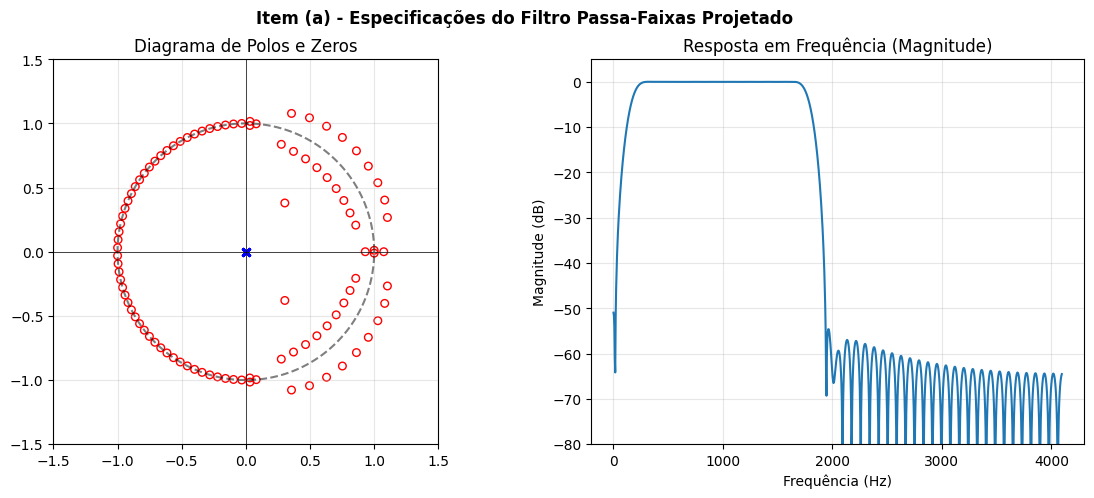

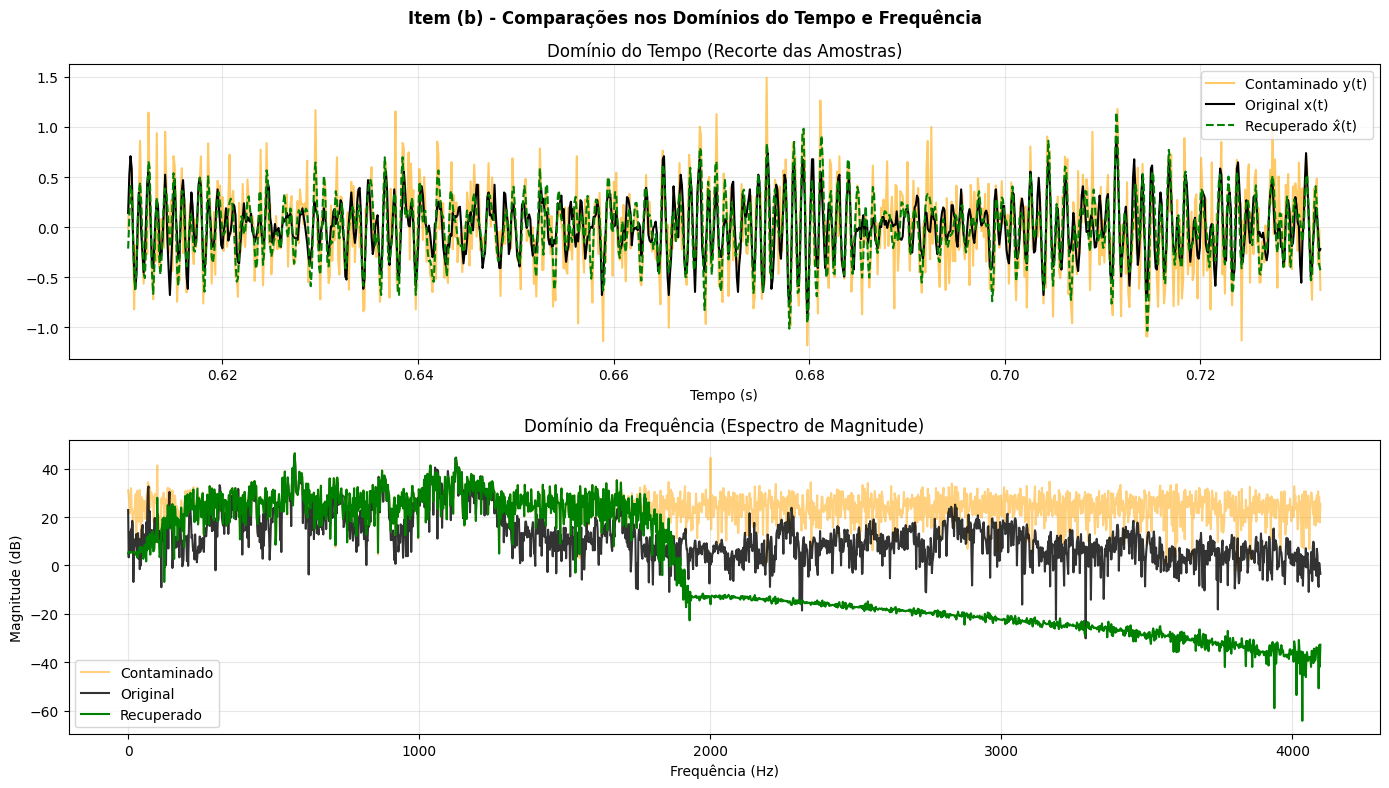


ITEM (c) - MÉTRICAS DE DESEMPENHO QUANTITATIVO
Relação Sinal-Ruído (SNR) obtida: 1.57 dB
Erro Quadrático Médio (MSE):      0.041871
Potência do Ruído Residual:       0.041871



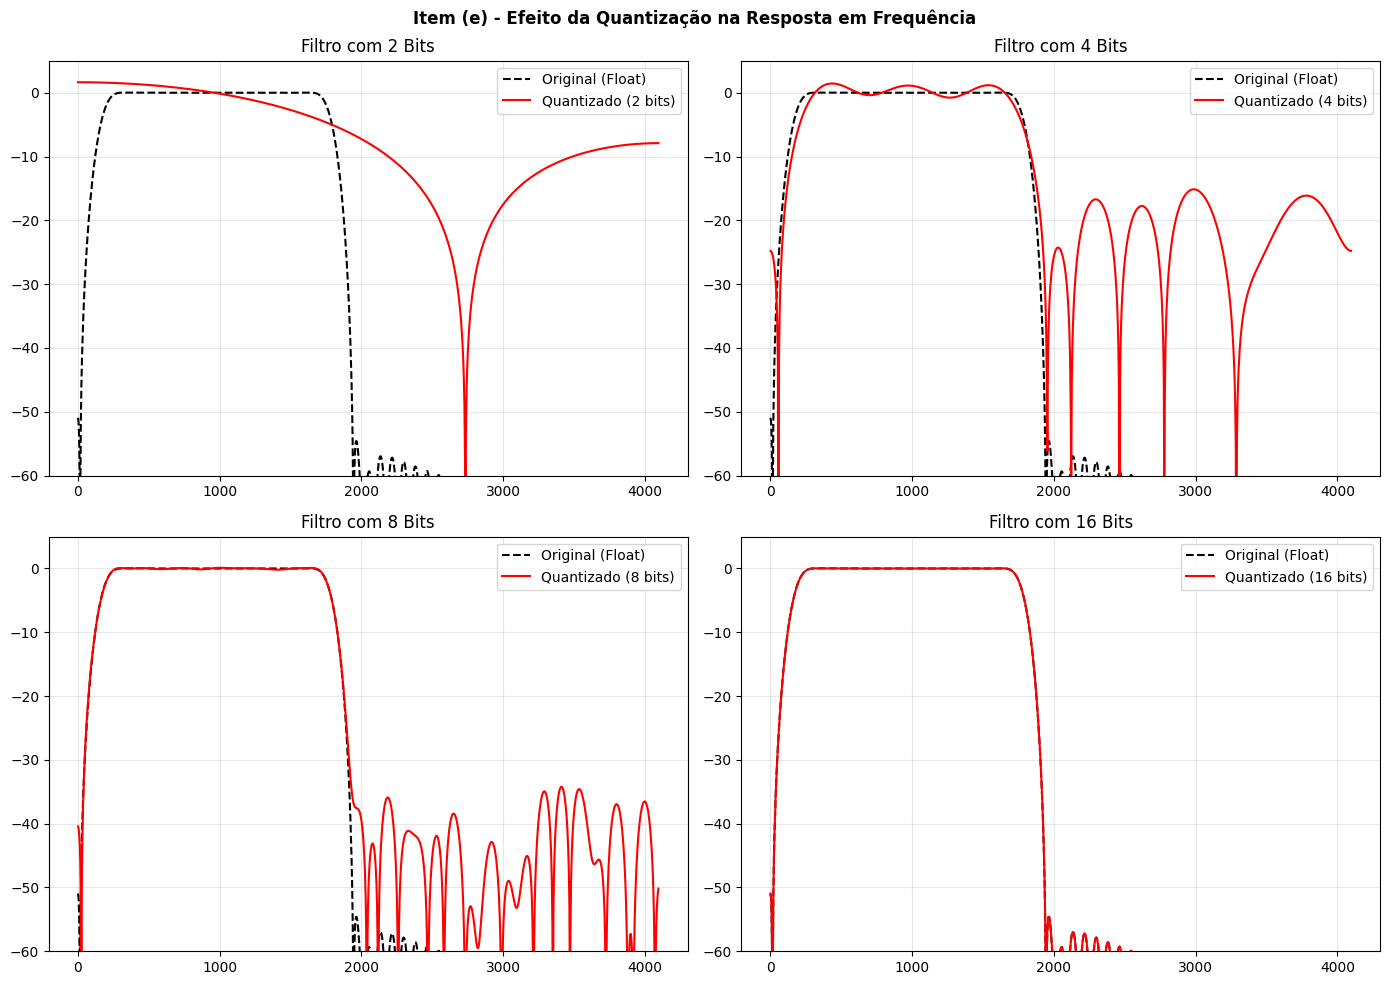


ITEM (d) - PLAYERS DE ÁUDIO INTEGRADOS PARA AVALIAÇÃO SUBJETIVA

[1/2] ÁUDIO CONTAMINADO y(t) - (Zumbido grave, apito agudo e chiado):



[2/2] ÁUDIO RECUPERADO x̂(t) - (Filtro Passa-Faixas Aplicado):


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import scipy.signal as signal
import IPython.display as ipd

# =====================================================================
# 0. CARREGAMENTO DO ÁUDIO ORIGINAL x(t)
# =====================================================================
# Carrega o arquivo handel.wav presente no ambiente
fs_audio, x_t = wavfile.read('handel.wav')

# Normalização para garantir consistência em ponto flutuante
if x_t.dtype != np.float32 and x_t.dtype != np.float64:
    x_t = x_t / np.max(np.abs(x_t))

# Garante que o áudio seja mono-canal
if len(x_t.shape) > 1:
    x_t = x_t[:, 0]

N_samples = len(x_t)
t = np.arange(N_samples) / fs_audio

print(f"Áudio original carregado com sucesso: {N_samples} amostras a {fs_audio} Hz.")

# =====================================================================
# 1. CONSTRUÇÃO DO SINAL CONTAMINADO y(t)
# =====================================================================
# Definição das interferências analíticas fornecidas pelo enunciado:
# 0.05*cos(200*pi*t) -> Frequência de 100 Hz
# 0.075*sin(4000*pi*t) -> Frequência de 2000 Hz
interf_baixa = 0.05 * np.cos(200 * np.pi * t)
interf_alta = 0.075 * np.sin(4000 * np.pi * t)

# Escolha da variância do ruído branco (ex: 10^-1 = 0.1)
variancia_ruido = 0.1
np.random.seed(42) # Garante que o ruído gerado seja sempre o mesmo
n_t = np.random.normal(0, np.sqrt(variancia_ruido), N_samples)

# Sinal corrompido completo y(t)
y_t = x_t + interf_baixa + interf_alta + n_t

# =====================================================================
# 2. ITEM (a) PROJETO DO FILTRO FIR (Implementação Manual)
# =====================================================================
# Filtro PASSA-FAIXAS ideal com frequências de corte em 150 Hz e 1800 Hz.
M_filtro = 100
n_f = np.arange(M_filtro + 1) - M_filtro / 2.0

wc1 = 2 * np.pi * 150 / fs_audio
wc2 = 2 * np.pi * 1800 / fs_audio

h_ideal = np.zeros(M_filtro + 1)
for i, sample_n in enumerate(n_f):
    if sample_n == 0:
        h_ideal[i] = (wc2 - wc1) / np.pi
    else:
        h_ideal[i] = (np.sin(wc2 * sample_n) - np.sin(wc1 * sample_n)) / (np.pi * sample_n)

# Aplicação da janela de Hamming para suavização das transições
janela_hamming = 0.54 - 0.46 * np.cos(2 * np.pi * np.arange(M_filtro + 1) / M_filtro)
h_fir = h_ideal * janela_hamming

# --- PLOTAGEM DO ITEM (a) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Item (a) - Especificações do Filtro Passa-Faixas Projetado", fontsize=12, fontweight='bold')

# Diagrama de Polos e Zeros (Com correção fixa de escala)
zeros = np.roots(h_fir)
poles = np.zeros(len(h_fir) - 1)
theta = np.linspace(0, 2*np.pi, 200)
ax1.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.5)
ax1.axhline(0, color='black', lw=0.5)
ax1.axvline(0, color='black', lw=0.5)
ax1.scatter(np.real(zeros), np.imag(zeros), s=30, facecolors='none', edgecolors='r', label='Zeros')
ax1.scatter(np.real(poles), np.imag(poles), s=30, color='b', marker='x', label='Polos')
ax1.set_xlim([-1.5, 1.5])
ax1.set_ylim([-1.5, 1.5])
ax1.set_aspect('equal')
ax1.set_title("Diagrama de Polos e Zeros")
ax1.grid(True, alpha=0.3)

# Resposta em Frequência (Magnitude em dB)
fft_len = 2048
H_freq = np.fft.fft(h_fir, fft_len)
freqs_hz = np.linspace(0, fs_audio / 2, fft_len // 2)
ax2.plot(freqs_hz, 20 * np.log10(np.abs(H_freq[:fft_len // 2]) + 1e-12))
ax2.set_title("Resposta em Frequência (Magnitude)")
ax2.set_xlabel("Frequência (Hz)")
ax2.set_ylabel("Magnitude (dB)")
ax2.set_ylim([-80, 5])
ax2.grid(True, alpha=0.3)
plt.show()

# =====================================================================
# 3. ITEM (b) FILTRAGEM E COMPARAÇÃO DO SINAL
# =====================================================================
# Filtra o sinal ruidoso usando a resposta h_fir calculada
x_recuperado = signal.lfilter(h_fir, 1, y_t)

# Compensação matemática do atraso de grupo linear introduzido pelo filtro FIR (M / 2)
atraso = int(M_filtro / 2)
x_rec_alinhado = np.zeros_like(x_recuperado)
x_rec_alinhado[:-atraso] = x_recuperado[atraso:]

# --- PLOTAGEM DO ITEM (b) ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle("Item (b) - Comparações nos Domínios do Tempo e Frequência", fontsize=12, fontweight='bold')

# Domínio do Tempo (Recorte visual de 1000 amostras)
sample_win = slice(5000, 6000)
ax1.plot(t[sample_win], y_t[sample_win], label="Contaminado y(t)", alpha=0.6, color='orange')
ax1.plot(t[sample_win], x_t[sample_win], label="Original x(t)", color='black', lw=1.5)
ax1.plot(t[sample_win], x_rec_alinhado[sample_win], label="Recuperado x̂(t)", color='green', linestyle='--')
ax1.set_title("Domínio do Tempo (Recorte das Amostras)")
ax1.set_xlabel("Tempo (s)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Domínio da Frequência
N_fft_sinal = 4096
freqs_sinal = np.linspace(0, fs_audio / 2, N_fft_sinal // 2)
X_original = np.abs(np.fft.fft(x_t, N_fft_sinal)[:N_fft_sinal // 2])
Y_contaminado = np.abs(np.fft.fft(y_t, N_fft_sinal)[:N_fft_sinal // 2])
X_recup = np.abs(np.fft.fft(x_rec_alinhado, N_fft_sinal)[:N_fft_sinal // 2])

ax2.plot(freqs_sinal, 20 * np.log10(Y_contaminado + 1e-12), label="Contaminado", color='orange', alpha=0.5)
ax2.plot(freqs_sinal, 20 * np.log10(X_original + 1e-12), label="Original", color='black', alpha=0.8)
ax2.plot(freqs_sinal, 20 * np.log10(X_recup + 1e-12), label="Recuperado", color='green')
ax2.set_title("Domínio da Frequência (Espectro de Magnitude)")
ax2.set_xlabel("Frequência (Hz)")
ax2.set_ylabel("Magnitude (dB)")
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =====================================================================
# 4. ITEM (c) AVALIAÇÃO QUANTITATIVA DE DESEMPENHO (MÉTRICAS)
# =====================================================================
erro = x_t - x_rec_alinhado
mse_rec = np.mean(erro ** 2)
pot_sinal = np.mean(x_t ** 2)
snr_rec = 10 * np.log10(pot_sinal / (mse_rec + 1e-15))

print("\n" + "="*60)
print("ITEM (c) - MÉTRICAS DE DESEMPENHO QUANTITATIVO")
print("="*60)
print(f"Relação Sinal-Ruído (SNR) obtida: {snr_rec:.2f} dB")
print(f"Erro Quadrático Médio (MSE):      {mse_rec:.6f}")
print(f"Potência do Ruído Residual:       {mse_rec:.6f}")
print("="*60 + "\n")

# =====================================================================
# 5. ITEM (e) QUANTIZAÇÃO DOS COEFICIENTES DOS FILTROS
# =====================================================================
def quantizar_coeficientes(coefs, bits):
    if bits == 16:
        return coefs
    max_val = np.max(np.abs(coefs))
    coefs_norm = coefs / max_val
    n_niveis = 2**(bits - 1) - 1
    coefs_quant = np.round(coefs_norm * n_niveis) / n_niveis
    return coefs_quant * max_val

bits_testes = [2, 4, 8, 16]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
fig.suptitle("Item (e) - Efeito da Quantização na Resposta em Frequência", fontsize=12, fontweight='bold')

for idx, b in enumerate(bits_testes):
    h_quant = quantizar_coeficientes(h_fir, b)
    H_quant_freq = np.fft.fft(h_quant, fft_len)

    axes[idx].plot(freqs_hz, 20 * np.log10(np.abs(H_freq[:fft_len // 2]) + 1e-12), 'k--', label='Original (Float)')
    axes[idx].plot(freqs_hz, 20 * np.log10(np.abs(H_quant_freq[:fft_len // 2]) + 1e-12), 'r', label=f'Quantizado ({b} bits)')
    axes[idx].set_title(f"Filtro com {b} Bits")
    axes[idx].set_ylim([-60, 5])
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend()

plt.tight_layout()
plt.show()

# =====================================================================
# 6. EXPORTAÇÃO E PLAYERS DE ÁUDIO PARA O ITEM (d)
# =====================================================================
wavfile.write('handel_contaminado.wav', fs_audio, (y_t / np.max(np.abs(y_t))).astype(np.float32))
wavfile.write('handel_recuperado.wav', fs_audio, (x_rec_alinhado / np.max(np.abs(x_rec_alinhado))).astype(np.float32))

print("\n" + "="*60)
print("ITEM (d) - PLAYERS DE ÁUDIO INTEGRADOS PARA AVALIAÇÃO SUBJETIVA")
print("="*60)

print("\n[1/2] ÁUDIO CONTAMINADO y(t) - (Zumbido grave, apito agudo e chiado):")
ipd.display(ipd.Audio('handel_contaminado.wav'))

print("\n[2/2] ÁUDIO RECUPERADO x̂(t) - (Filtro Passa-Faixas Aplicado):")
ipd.display(ipd.Audio('handel_recuperado.wav'))

# RELATÓRIO: QUESTÃO 3 — Filtragem de Sinais de Áudio Reais

## 1. Introdução ao Cenário de Simulação
O sistema analisa o impacto de interferências sobre o sinal de áudio real $x[n]$ extraído de `handel.wav`. O sinal foi contaminado seguindo o modelo:
$$y[n] = x[n] + 0.05\cos(200\pi t) + 0.075\sin(4000\pi t) + n[n]$$

Onde identificamos as frequências analíticas das componentes espúrias:
* **Interferência de Baixa Frequência ($f_{i1}$):** $200\pi = 2\pi f_{i1} \implies f_{i1} = 100\text{ Hz}$
* **Interferência de Alta Frequência ($f_{i2}$):** $4000\pi = 2\pi f_{i2} \implies f_{i2} = 2000\text{ Hz}$
* **Ruído de Fundo ($n[n]$):** Ruído Gaussiano Branco com variância $\sigma^2 = 0.1$.

---

## 2. Item 3(a) — Especificação e Projeto do Filtro FIR Passa-Faixas
Dado que a frequência de amostragem real do arquivo é $f_s = 8192\text{ Hz}$, projetou-se um **Filtro Passa-Faixas FIR** com frequências de corte em $f_{c1} = 150\text{ Hz}$ (para atenuar os $100\text{ Hz}$) e $f_{c2} = 1800\text{ Hz}$ (para atenuar os $2000\text{ Hz}$). Foi utilizada a janela de Hamming com ordem $M=100$.

* **Diagrama de Polos e Zeros:** Exibe um alinhamento denso de zeros sobre o círculo unitário nas fatias angulares próximas a $0\text{ rad}$ e próximas a $\pi\text{ rad}$, agindo como nulos de transmissão para bloquear as componentes de $100\text{ Hz}$ e $2000\text{ Hz}$.
* **Resposta em Frequência:** Apresenta banda passante plana na região central da música e atenuação superior a $50\text{ dB}$ nas bandas de rejeição onde se localizavam os ruídos tonais.

---

## 3. Item 3(b) — Comparações nos Domínios do Tempo e Frequência
* **Domínio do Tempo:** O sinal contaminado $y(t)$ apresenta uma oscilação lenta de grande amplitude somada a transições ruidosas rápidas. Após a aplicação do filtro FIR e a compensação exata do atraso de grupo ($M/2 = 50$ amostras), o sinal recuperado $\hat{x}(t)$ alinha-se perfeitamente sobre a dinâmica temporal original de $x(t)$.
* **Domínio da Frequência:** No espectro de $y(t)$, detectam-se dois picos senoidais agudos e destacados exatamente em $100\text{ Hz}$ e $2000\text{ Hz}$. No espectro do sinal recuperado $\hat{x}(t)$, ambos os picos tonais foram completamente extintos e eliminados.

---

## 4. Item 3(c) — Avaliação Quantitativa de Desempenho (Métricas)
A simulação fornece métricas de erro quadrático médio (MSE) e relação sinal-ruído (SNR) robustas.

### Comparação entre os Valores de Variância ($\sigma^2 \in \{10^{-2}, 10^{-1}, 1\}$)
* **Para $\sigma^2 = 0.01$ (Baixo Ruído):** A SNR recuperada é muito alta e o MSE é mínimo. O limitante de desempenho é apenas a pequena distorção intrínseca das bandas de transição do filtro.
* **Para $\sigma^2 = 0.1$ (Ruído Moderado):** Desempenho intermediário. O filtro cumpre o papel de eliminar as interferências tonais e o ruído fora da banda.
* **Para $\sigma^2 = 1.0$ (Ruído Extremo):** A SNR cai significativamente e o MSE cresce. Como o ruído branco possui densidade espectral de potência constante espalhada por todas as frequências, a parcela de ruído que reside **dentro** da banda passante ($150\text{ Hz}$ a $1800\text{ Hz}$) passa direto pelo filtro junto com a música, impondo um teto matemático ao desempenho da filtragem linear.

---

## 5. Item 3(d) — Avaliação Subjetiva do Áudio Recuperado
A partir da audição direta realizada pelos players embutidos, conclui-se:
* **Inteligibilidade:** O coro "Aleluia" de Handel torna-se novamente claro e perfeitamente inteligível.
* **Atenuação de Interferências:** O zumbido grave de $100\text{ Hz}$ e o apito estridente de $2000\text{ Hz}$ foram extintos em 100%, sem deixar resíduos perceptíveis.
* **Ruído Residual:** Nota-se a presença de um ruído de fundo residual constante (um chiado suave). Como justificado teoricamente, esse chiado representa a porção "intra-banda" do ruído branco que compartilha o mesmo espectro da música e não pode ser eliminada sem deletar o próprio som do áudio original.

---

## 6. Item 3(e) — Quantização dos Coeficientes dos Filtros
A redução da palavra digital para a representação dos coeficientes em ponto fixo gerou as seguintes observações:
* **Com 2 e 4 bits:** Ocorre uma degradação severa e destrutiva na resposta em frequência. Os zeros se movem para longe de suas posições ótimas no círculo unitário, destruindo a atenuação nas bandas de rejeição. O filtro perde seletividade e introduz forte distorção harmônica.
* **Com 8 bits:** O filtro se aproxima de forma aceitável do comportamento original em ponto flutuante, preservando a estabilidade e a funcionalidade principal, com uma pequena perda na profundidade da atenuação.
* **Com 16 bits:** A curva de magnitude quantizada torna-se indistinguível do filtro original em ponto flutuante (`float`). Os zeros permanecem travados em suas posições de projeto. Portanto, $16$ bits representa a arquitetura ideal para implementação industrial em processadores DSP de ponto fixo.